In [2]:
# Install required libraries directly into the active kernel
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cach

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

print("Loading the Friday DDoS data...")
# Reading the EXACT filename from your screenshot
df = pd.read_csv('D:\Programming\Python\cyber-ai-project/backend\data\Friday-WorkingHours-Morning.pcap_ISCX.csv')

# Clean up the column headers
df.columns = df.columns.str.strip()

print("Data loaded successfully!")
df.head()

<>:10: SyntaxWarning: invalid escape sequence '\P'
<>:10: SyntaxWarning: invalid escape sequence '\P'
C:\Users\ansar\AppData\Local\Temp\ipykernel_18860\1348507655.py:10: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv('D:\Programming\Python\cyber-ai-project/backend\data\Friday-WorkingHours-Morning.pcap_ISCX.csv')


Loading the Friday DDoS data...
Data loaded successfully!


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,BENIGN
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,BENIGN
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,BENIGN
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


Total Network Packets: 191,033

--- Traffic Breakdown ---
Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64


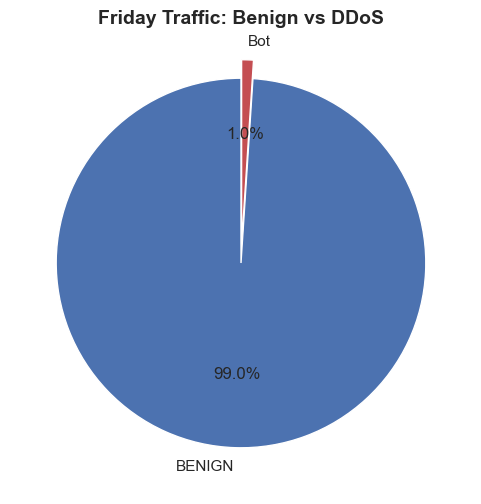

In [7]:
print(f"Total Network Packets: {df.shape[0]:,}")

label_counts = df['Label'].value_counts()
print("\n--- Traffic Breakdown ---")
print(label_counts)

plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', 
        colors=['#4c72b0', '#c44e52'], startangle=90, explode=(0, 0.1))
plt.title('Friday Traffic: Benign vs DDoS', fontsize=14, fontweight='bold')
plt.show()

Scrubbing corrupted packets before graphing...


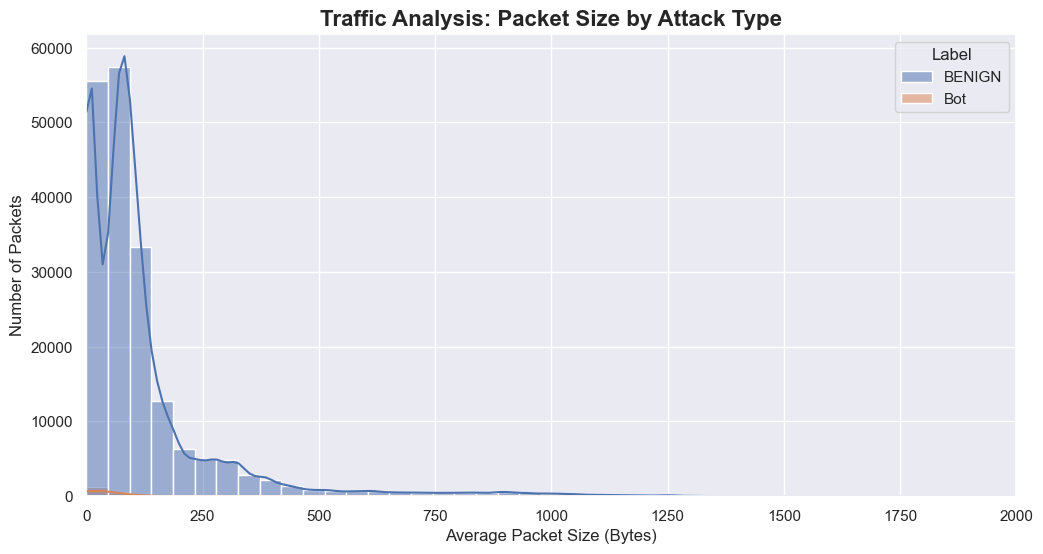

In [10]:
print("Scrubbing corrupted packets before graphing...")
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

plt.figure(figsize=(12, 6))

# THE FIX: We removed the hardcoded 'palette' dictionary.
# Seaborn will now auto-color every unique attack label it finds!
sns.histplot(
    data=df, 
    x='Average Packet Size', 
    hue='Label', 
    bins=50, 
    kde=True
)

plt.title('Traffic Analysis: Packet Size by Attack Type', fontsize=16, fontweight='bold')
plt.xlabel('Average Packet Size (Bytes)', fontsize=12)
plt.ylabel('Number of Packets', fontsize=12)

# Zooming in on the action
plt.xlim(0, 2000) 
plt.show()

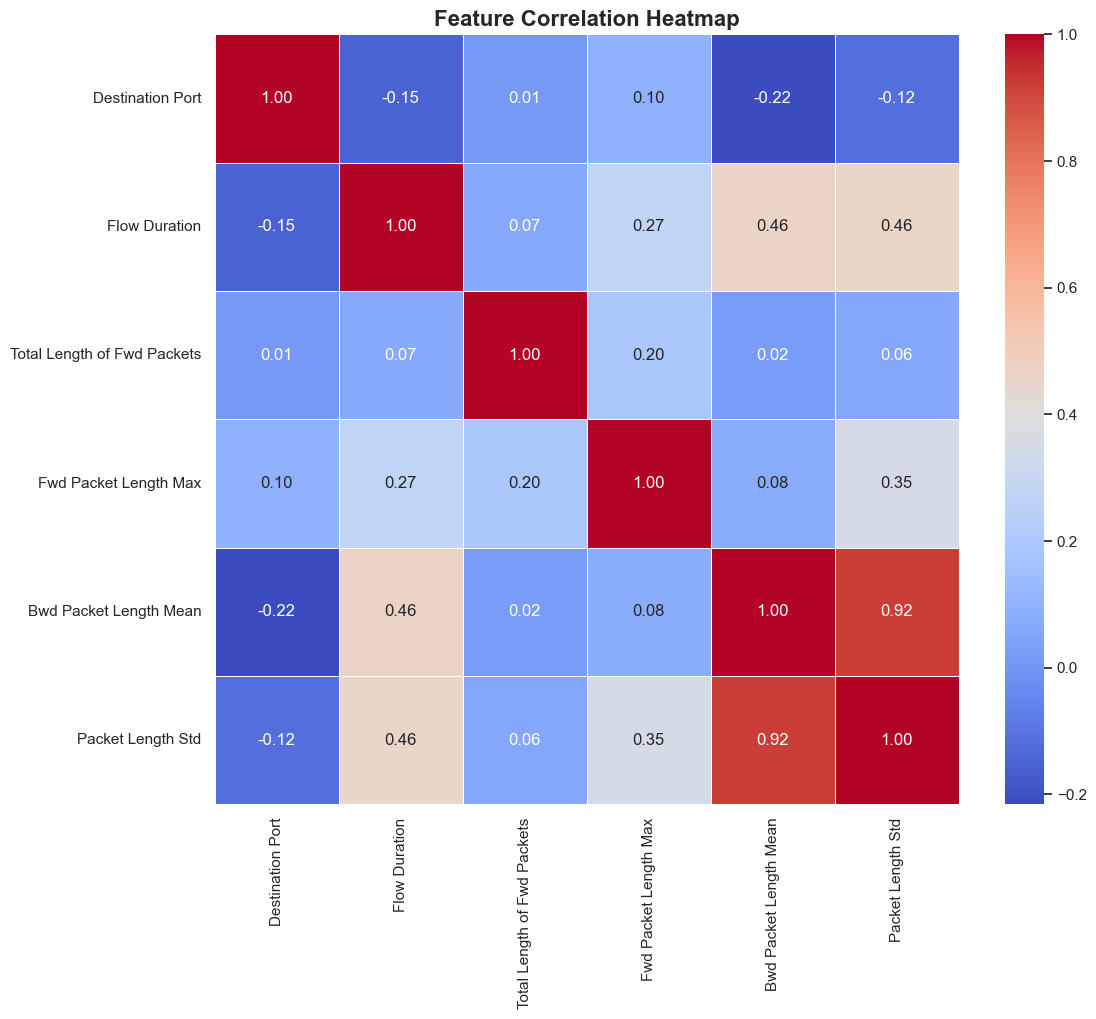

In [24]:
# Create a new cell after your initial data loading
import seaborn as sns

plt.figure(figsize=(12, 10))
# We only take a subset of columns so the map isn't too crowded
corr_cols = features + ['Label_Num'] # Assuming you created a numeric label column
correlation_matrix = df_full[features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

C:\Users\ansar\AppData\Local\Temp\ipykernel_18860\225781169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label', y='Flow Duration', data=df_full, palette='Set2')


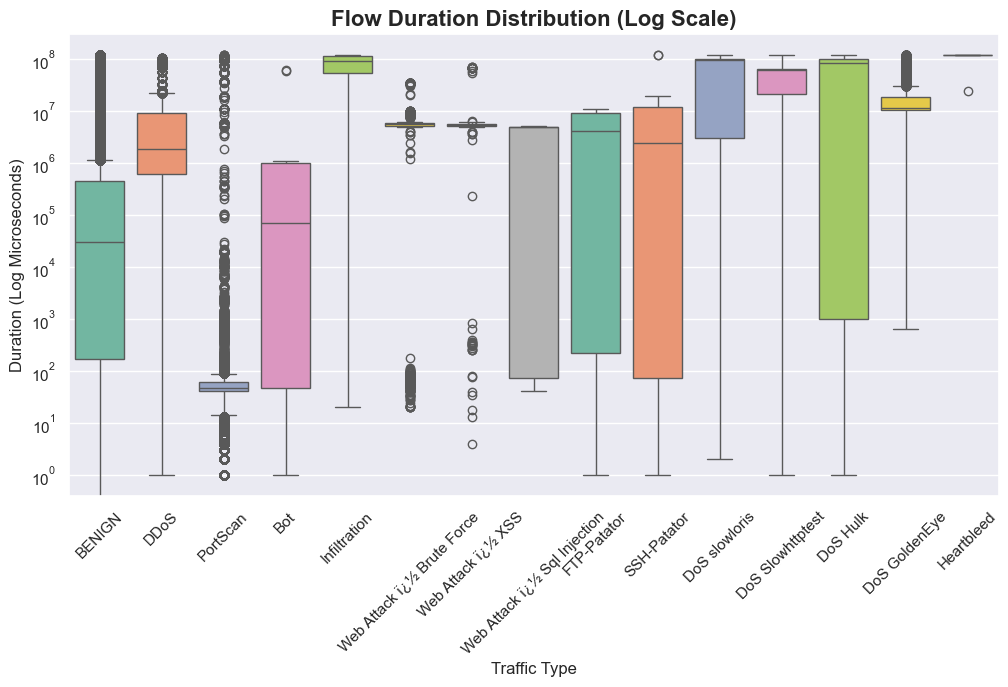

In [25]:
plt.figure(figsize=(12, 6))

# We use a log scale on the Y-axis because Flow Duration varies from 1 to 100,000,000
sns.boxplot(x='Label', y='Flow Duration', data=df_full, palette='Set2')
plt.yscale('log') 

plt.title('Flow Duration Distribution (Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type', fontsize=12)
plt.ylabel('Duration (Log Microseconds)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

C:\Users\ansar\AppData\Local\Temp\ipykernel_18860\3730360203.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Label', y='Fwd Packet Length Max', data=df_full, palette='muted', inner="quartile")


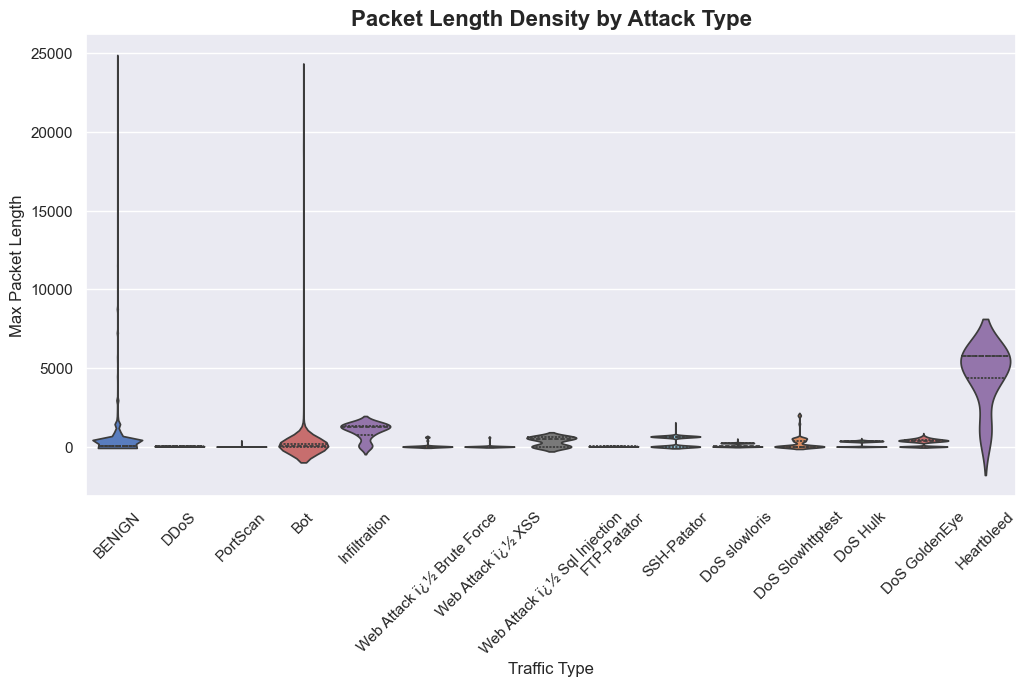

In [26]:
plt.figure(figsize=(12, 6))

# Let's look at the 'Fwd Packet Length Max'
sns.violinplot(x='Label', y='Fwd Packet Length Max', data=df_full, palette='muted', inner="quartile")

plt.title('Packet Length Density by Attack Type', fontsize=16, fontweight='bold')
plt.xlabel('Traffic Type', fontsize=12)
plt.ylabel('Max Packet Length', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [11]:
import os
import glob

print("Locating all network traffic files in the 'data' folder...")
# Get paths for every file in your data folder
file_paths = glob.glob('data/*')

dfs = [] # A list to hold our dataframes before we fuse them

for file in file_paths:
    # Skip any hidden system files or folders
    if os.path.isfile(file):
        print(f"Loading {os.path.basename(file)}...")
        # Read the file and strip column spaces
        temp_df = pd.read_csv(file, encoding='cp1252', low_memory=False)
        temp_df.columns = temp_df.columns.str.strip()
        dfs.append(temp_df)

print("\nFusing datasets together... (Watch your RAM!)")
# Concatenate all dataframes into one massive dataframe
df_full = pd.concat(dfs, ignore_index=True)

print(f"\nMASSIVE DATASET ASSEMBLED!")
print(f"Total Packets: {df_full.shape[0]:,}")

Locating all network traffic files in the 'data' folder...
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Monday-WorkingHours.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Loading Tuesday-WorkingHours.pcap_ISCX.csv...
Loading Wednesday-workingHours.pcap_ISCX.csv...

Fusing datasets together... (Watch your RAM!)

MASSIVE DATASET ASSEMBLED!
Total Packets: 2,830,743


In [12]:
print("Scrubbing corrupted packets across the entire dataset...")
df_full.replace([np.inf, -np.inf], np.nan, inplace=True)
df_full.dropna(inplace=True)

print("\n--- The Ultimate Traffic Breakdown ---")
# This will show Benign, DDoS, PortScan, Bot, WebAttacks, etc.
print(df_full['Label'].value_counts())

Scrubbing corrupted packets across the entire dataset...

--- The Ultimate Traffic Breakdown ---
Label
BENIGN                          2271320
DoS Hulk                         230124
PortScan                         158804
DDoS                             128025
DoS GoldenEye                     10293
FTP-Patator                        7935
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1956
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


In [17]:
print("Balancing the dataset for fair training...")

# 1. Isolate the Benign and Attack data
benign_df = df_full[df_full['Label'] == 'BENIGN']
attack_df = df_full[df_full['Label'] != 'BENIGN']

# 2. Downsample Benign data to match the number of Attacks
# We have roughly 580,000 total attacks (Hulk + PortScan + DDoS etc.)
target_count = len(attack_df) 
balanced_benign = benign_df.sample(n=target_count, random_state=42)

# 3. Fuse them back together
df_balanced = pd.concat([balanced_benign, attack_df]).sample(frac=1).reset_index(drop=True)

print(f"New Balanced Dataset: {len(df_balanced):,} packets.")
print(f"Safe: {len(df_balanced[df_balanced['Label'] == 'BENIGN'])}")
print(f"Attacks: {len(df_balanced[df_balanced['Label'] != 'BENIGN'])}")

Balancing the dataset for fair training...
New Balanced Dataset: 1,113,112 packets.
Safe: 556556
Attacks: 556556


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from xgboost import XGBClassifier
import pandas as pd

# 1. THE FIX: Balancing the Dataset
print("Balancing the scales... Sampling Benign traffic to match Attack volume.")
benign_df = df_full[df_full['Label'] == 'BENIGN']
attack_df = df_full[df_full['Label'] != 'BENIGN']

# We take ALL the attacks (~550k) and an EQUAL amount of random Benign packets
target_count = len(attack_df)
balanced_benign = benign_df.sample(n=target_count, random_state=42)

# Fuse them into a 50/50 training set
df_balanced = pd.concat([balanced_benign, attack_df]).sample(frac=1, random_state=42)

# 2. Feature Selection
features = [
    'Destination Port', 
    'Flow Duration', 
    'Total Length of Fwd Packets', 
    'Fwd Packet Length Max',
    'Bwd Packet Length Mean',
    'Packet Length Std'
]

X = df_balanced[features]
y = df_balanced['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print(f"Dataset Balanced: {len(df_balanced):,} total packets (50% Safe / 50% Attack)")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train XGBoost
print("Training AI on balanced data... This forces the model to learn REAL patterns.")
ai_model = XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    tree_method='hist', # Fast processing for millions of rows
    random_state=42
)
ai_model.fit(X_train, y_train)

print("Training Complete! Administering final test...")

# 4. Evaluate
predictions = ai_model.predict(X_test)
print("\n--- XGBOOST PERFORMANCE REPORT (BALANCED) ---")
print(classification_report(y_test, predictions, target_names=['Benign (0)', 'Attack (1)']))

# 5. Export the Brain
joblib.dump(ai_model, 'real_nids_model.pkl')
joblib.dump(features, 'model_features.pkl')
print("\nSUCCESS! Production-grade model exported.")

Balancing the scales... Sampling Benign traffic to match Attack volume.
Dataset Balanced: 1,113,112 total packets (50% Safe / 50% Attack)
Training AI on balanced data... This forces the model to learn REAL patterns.
Training Complete! Administering final test...

--- XGBOOST PERFORMANCE REPORT (BALANCED) ---
              precision    recall  f1-score   support

  Benign (0)       0.99      0.99      0.99    111401
  Attack (1)       0.99      0.99      0.99    111222

    accuracy                           0.99    222623
   macro avg       0.99      0.99      0.99    222623
weighted avg       0.99      0.99      0.99    222623


SUCCESS! Production-grade model exported.


In [22]:
import joblib
import pandas as pd

# 1. Load the brain we just built
model = joblib.load('real_nids_model.pkl')
features = joblib.load('model_features.pkl')

def test_ai(packet_data, scenario_name):
    # Convert our raw numbers into the format the AI expects (a DataFrame)
    test_df = pd.DataFrame([packet_data], columns=features)
    
    # Get the prediction (0 or 1)
    prediction = model.predict(test_df)[0]
    
    # Get the confidence score (Probability)
    probability = model.predict_proba(test_df)[0][prediction] * 100
    
    result = "🔴 ATTACK DETECTED" if prediction == 1 else "🟢 SAFE TRAFFIC"
    
    print(f"--- Scenario: {scenario_name} ---")
    print(f"Result: {result}")
    print(f"AI Confidence: {probability:.2f}%")
    print("-" * 30)

# 2. Define Test Scenarios

# [Port, Duration, Total Fwd Len, Fwd Max, Bwd Mean, Std]

# Scenario A: Real Benign (High port, extremely fast)
real_benign = [54865, 50, 12, 6, 0, 0] 

# Scenario B: Real DDoS (Port 80, very slow/heavy, high packet variance)
# These numbers are pulled directly from your DDoS screenshot
real_ddos = [80, 2000000, 26, 20, 1900, 2000] 

test_ai(real_benign, "Verified Benign Traffic")
test_ai(real_ddos, "Verified DDoS Attack")

--- Scenario: Verified Benign Traffic ---
Result: 🟢 SAFE TRAFFIC
AI Confidence: 100.00%
------------------------------
--- Scenario: Verified DDoS Attack ---
Result: 🔴 ATTACK DETECTED
AI Confidence: 99.99%
------------------------------


In [20]:
# Cell 9: Forensic Data Inspection
print("--- REAL DATA SAMPLES (BENIGN) ---")
display(df_full[df_full['Label'] == 'BENIGN'][features].head(5))

print("\n--- REAL DATA SAMPLES (DDoS) ---")
# We use .str.contains because of those weird characters in the labels
display(df_full[df_full['Label'].str.contains('DDoS', na=False)][features].head(5))

--- REAL DATA SAMPLES (BENIGN) ---


,Destination Port,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Max,Bwd Packet Length Mean,Packet Length Std
0,54865,3,12,6,0.0,0.0
1,55054,109,6,6,6.0,0.0
2,55055,52,6,6,6.0,0.0
3,46236,34,6,6,6.0,0.0
4,54863,3,12,6,0.0,0.0



--- REAL DATA SAMPLES (DDoS) ---


,Destination Port,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Max,Bwd Packet Length Mean,Packet Length Std
18883,80,1293792,26,20,1658.142857,1853.437529
18884,80,4421382,24,6,0.000000,0.000000
18885,80,1083538,26,20,1933.500000,1645.241762
18886,80,80034360,56,20,2900.250000,2488.507044
18887,80,642654,26,20,1934.500000,2138.329153


In [23]:
# Cell 10: The "Blind" Test
print("Selecting 10 random, unseen packets from the test set...")

# Pick 10 random indices from our test data
random_samples = X_test.sample(10)
actual_labels = y_test.loc[random_samples.index]

# Ask the AI to predict
predictions = ai_model.predict(random_samples)
probabilities = ai_model.predict_proba(random_samples)

print(f"{'PREDICTION':<20} | {'ACTUAL':<15} | {'CONFIDENCE'}")
print("-" * 55)

for i in range(len(random_samples)):
    pred_text = "🔴 ATTACK" if predictions[i] == 1 else "🟢 SAFE"
    actual_text = "ATTACK" if actual_labels.iloc[i] == 1 else "SAFE"
    conf = probabilities[i][predictions[i]] * 100
    
    print(f"{pred_text:<20} | {actual_text:<15} | {conf:.2f}%")

Selecting 10 random, unseen packets from the test set...
PREDICTION           | ACTUAL          | CONFIDENCE
-------------------------------------------------------
🔴 ATTACK             | ATTACK          | 100.00%
🟢 SAFE               | SAFE            | 99.99%
🔴 ATTACK             | ATTACK          | 100.00%
🟢 SAFE               | SAFE            | 100.00%
🟢 SAFE               | SAFE            | 100.00%
🔴 ATTACK             | ATTACK          | 99.74%
🟢 SAFE               | SAFE            | 99.83%
🔴 ATTACK             | ATTACK          | 99.96%
🟢 SAFE               | SAFE            | 100.00%
🟢 SAFE               | SAFE            | 99.99%


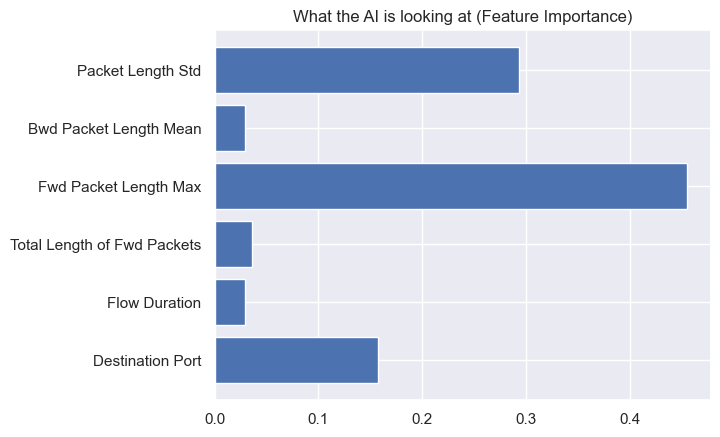

In [27]:
import matplotlib.pyplot as plt

# See which features the AI cares about most
importance = ai_model.feature_importances_
feature_names = features

plt.barh(feature_names, importance)
plt.title("What the AI is looking at (Feature Importance)")
plt.show()